### What is Hierarchical Clustering?

##### Hierarchical Clustering is an unsupervised machine learning algorithm used to group similar data points into clusters.

##### Unlike K-Means, it does not require us to specify the clusters during the clustering process. Instead, it builds a tree-like structure (Dendrogram) showing how clusters are formed.

### Types of Hierarchical Clustering

## - **1. Agglomerative Hierarchical Clustering (Bottom-Up)**

###  Agglomerative Hierarchical Clustering (Bottom-Up)

```text
┌──────────────────────────────┐
│ 100 Data Samples             │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│ Each Sample = One Cluster    │
│ Total Clusters = 100         │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│ Merge Two Closest Clusters   │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│ Total Clusters = 99          │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│ Merge Again                  │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│ Total Clusters = 98          │
└──────────────┬───────────────┘
               │
               ▼
              ...
               │
               ▼
┌──────────────────────────────┐
│ Finally Only One Cluster     │
└──────────────────────────────┘
```

## - **2. Divisive Hierarchical Clustering (Top-Down)**

# Divisive Hierarchical Clustering (Top-Down)

```text
┌──────────────────────────────┐
│        100 Data Samples      │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│      One Large Cluster       │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│ Split into Two Clusters      │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│ Split Each Cluster Again     │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│ Continue Splitting           │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│ Every Sample Becomes         │
│ an Individual Cluster        │
└──────────────────────────────┘
```

### When should we use Hierarchical Clustering?

    - **Dataset size is small or medium.**
    - **You don't know how many clusters exist.**
    - **You want to visualize relationships between observations.**
    - **You need a dendrogram.**
    - **You want to understand how clusters are formed.**  

### Silhouette Score

##### Silhouette Score measures how good the clustering is.
- **How close a point is to its own cluster.**
- **How far it is from the nearest neighboring cluster.**

### Implementing Agglomerative Hierarichal Clustering

In [1]:
import pandas as pd

df = pd.read_csv(r"E:\sculptsoft\1 July\Wholesale customers data.csv")
df.head()

C:\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [2]:
# Scaling the datraframe

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [3]:

X_scaled.shape


(440, 8)

In [4]:
# Applying PCA 

from sklearn.decomposition import PCA

pca = PCA(n_components=4)
pca_scaled = pca.fit_transform(X_scaled)

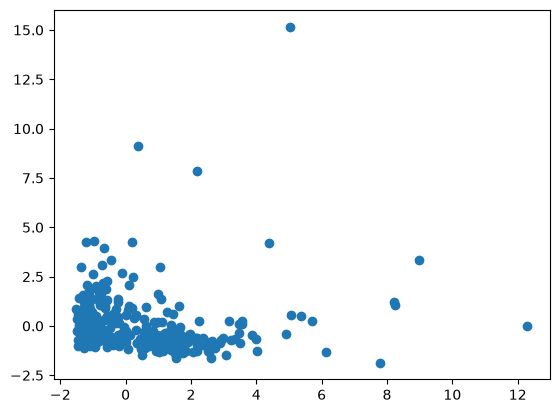

In [5]:
import  matplotlib.pyplot as plt
plt.scatter(pca_scaled[:,0],pca_scaled[:,1])

In [6]:
pca

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",4
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [7]:
pca_scaled

array([[ 0.84393893, -0.51535075,  0.76763222,  0.0442148 ],
       [ 1.06267645, -0.48460126,  0.67297526, -0.40137178],
       [ 1.26914052,  0.68205455,  0.6640946 , -1.63495276],
       ...,
       [ 3.86514909, -0.47985376,  0.52534452,  0.68713197],
       [-1.09706738, -0.06989568,  0.63012755, -0.31182088],
       [-1.16595067, -0.90215675,  0.59770486, -0.34265555]],
      shape=(440, 4))

{'icoord': [[15.0, 15.0, 25.0, 25.0],
  [5.0, 5.0, 20.0, 20.0],
  [35.0, 35.0, 45.0, 45.0],
  [85.0, 85.0, 95.0, 95.0],
  [75.0, 75.0, 90.0, 90.0],
  [65.0, 65.0, 82.5, 82.5],
  [55.0, 55.0, 73.75, 73.75],
  [40.0, 40.0, 64.375, 64.375],
  [12.5, 12.5, 52.1875, 52.1875],
  [105.0, 105.0, 115.0, 115.0],
  [135.0, 135.0, 145.0, 145.0],
  [125.0, 125.0, 140.0, 140.0],
  [110.0, 110.0, 132.5, 132.5],
  [165.0, 165.0, 175.0, 175.0],
  [155.0, 155.0, 170.0, 170.0],
  [185.0, 185.0, 195.0, 195.0],
  [225.0, 225.0, 235.0, 235.0],
  [215.0, 215.0, 230.0, 230.0],
  [205.0, 205.0, 222.5, 222.5],
  [190.0, 190.0, 213.75, 213.75],
  [162.5, 162.5, 201.875, 201.875],
  [121.25, 121.25, 182.1875, 182.1875],
  [32.34375, 32.34375, 151.71875, 151.71875],
  [255.0, 255.0, 265.0, 265.0],
  [245.0, 245.0, 260.0, 260.0],
  [285.0, 285.0, 295.0, 295.0],
  [275.0, 275.0, 290.0, 290.0],
  [252.5, 252.5, 282.5, 282.5],
  [325.0, 325.0, 335.0, 335.0],
  [315.0, 315.0, 330.0, 330.0],
  [305.0, 305.0, 322.5, 322.

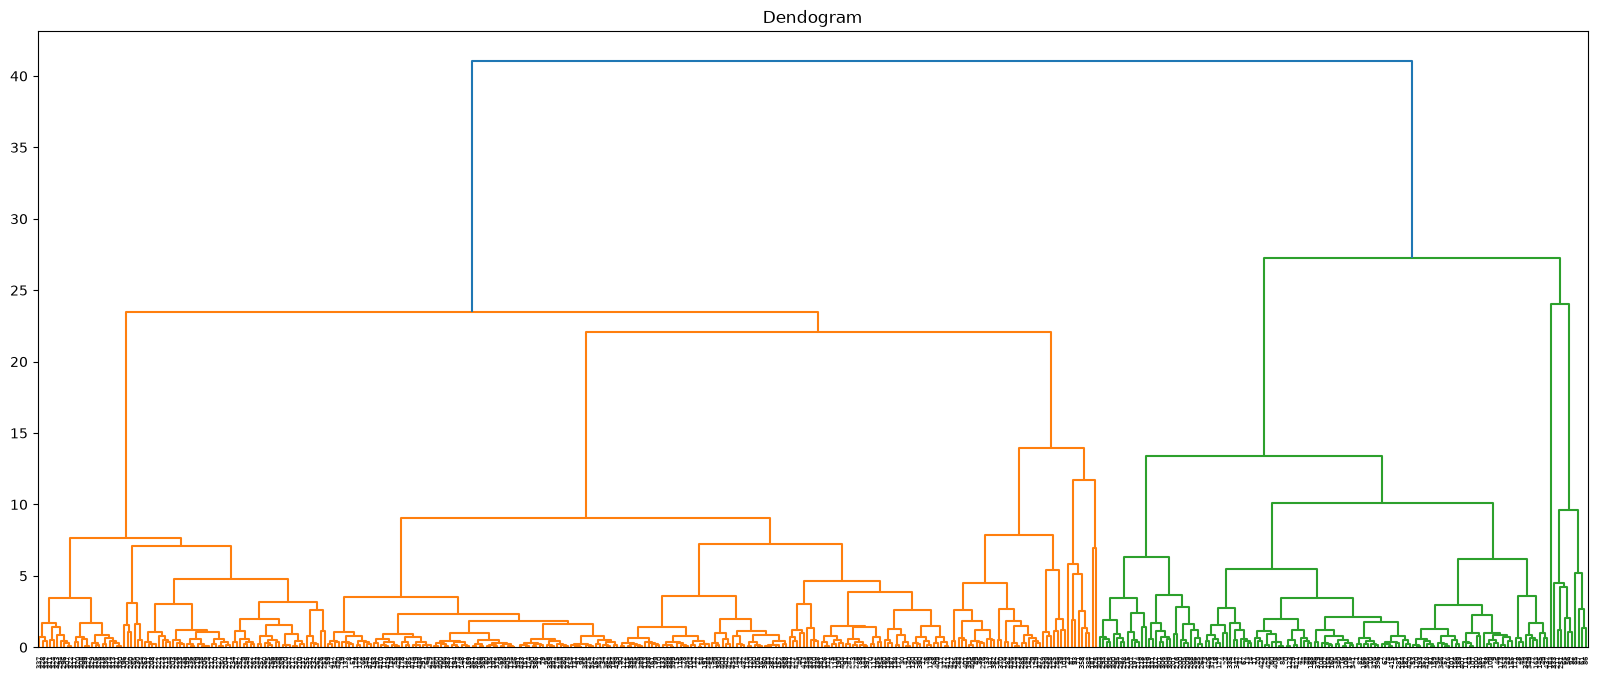

In [20]:
# Construction of dendogram for clustering

import scipy.cluster.hierarchy as sc

plt.figure(figsize=(20,8))
plt.title("Dendogram")

sc.dendrogram(sc.linkage(pca_scaled,method = "ward"))

In [9]:
from sklearn.cluster import AgglomerativeClustering

clustering = AgglomerativeClustering(n_clusters= 2, metric='euclidean', linkage='ward')
clustering.fit(pca_scaled)

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",2
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" and ""l2"" are accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'ward'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",None
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False
Name,Type,Value
"children_ children_: array-like of shape (n_samples-1, 2)The children of each non-leaf node. Values less than `n_samples`correspond to leaves of the tree which are the original samples.A node `i` greater than or equal to `n_sampl

In [10]:
clustering.labels_

array([0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0,

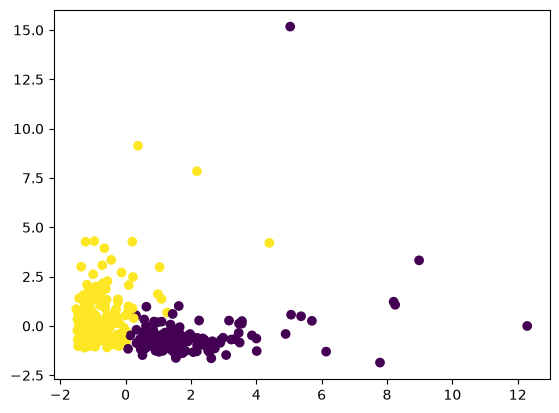

In [11]:
plt.scatter(pca_scaled[:,0],pca_scaled[:,1], c= clustering.labels_)

In [ ]:
# Calculating the Silhouette Score of PCA

from sklearn.metrics import silhouette_score

silhouette_coefficent = []

for k in range(2,11):
    agglo = AgglomerativeClustering(n_clusters=k, metric = "euclidean", linkage = "ward")
    agglo.fit(pca_scaled)
    score = silhouette_score(pca_scaled, agglo.labels_)
    silhouette_coefficent.append(score)


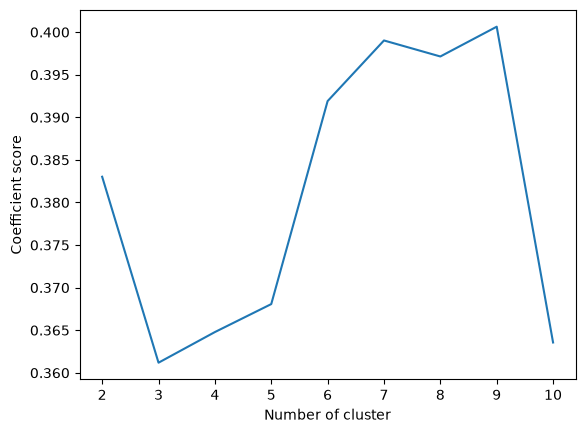

In [14]:
plt.plot(range(2,11), silhouette_coefficent)
plt.xticks(range(2,11))
plt.xlabel("Number of cluster")
plt.ylabel("Coefficient score")
plt.show()

In [ ]:
# Calculating the silhouette score whitout pca

silhouette_coefficent_X_labeled = []

for k in range(2,11):
    agglo = AgglomerativeClustering(n_clusters=k, metric = "euclidean", linkage = "ward")
    agglo.fit(X_scaled)
    score = silhouette_score(X_scaled, agglo.labels_)
    silhouette_coefficent_X_labeled.append(score)


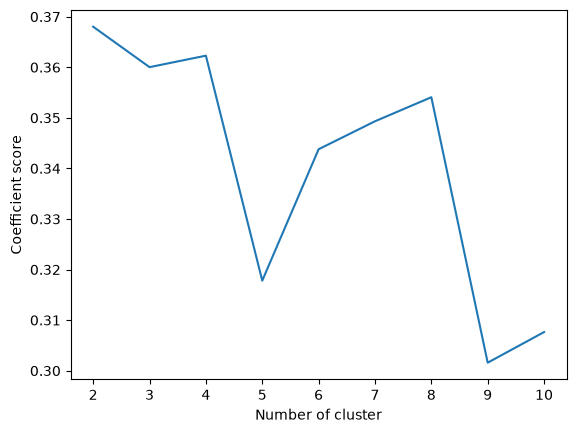

In [ ]:
plt.plot(range(2,11), silhouette_coefficent_X_labeled)
plt.xticks(range(2,11))
plt.xlabel("Number of cluster")
plt.ylabel("Coefficient score")
plt.show()